# Skin Lesion Classification using Deep Learning

This project focuses on classifying skin lesions into multiple diagnostic categories using deep learning models.

Different CNN architectures are trained and evaluated, including custom CNN models and pretrained transfer learning models such as EfficientNetB0, and ResNet50.

The models are compared using multiple evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix analysis.

## Importing Required Libraries

The following libraries are used for:

- Image preprocessing
- Data augmentation
- Model building
- Transfer learning
- Performance evaluation
- Visualization of results

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-06-28 13:49:43.728784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782654583.888942      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782654583.939532      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782654584.317794      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782654584.317831      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782654584.317833      58 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = "/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train"

Loading images

In [3]:
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


I0000 00:00:1782654598.196519      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782654598.202311      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2239 files belonging to 9 classes.
Using 447 files for validation.


## Class Distribution Analysis

The number of images differs significantly across the different classes.

This imbalance can cause models to become biased towards majority classes and perform poorly on underrepresented classes.

To overcome this issue, data augmentation and class balancing techniques are applied.

In [4]:
class_names = train_ds.class_names

print(class_names)
print(f"number of classes: {len(class_names)}")

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
number of classes: 9


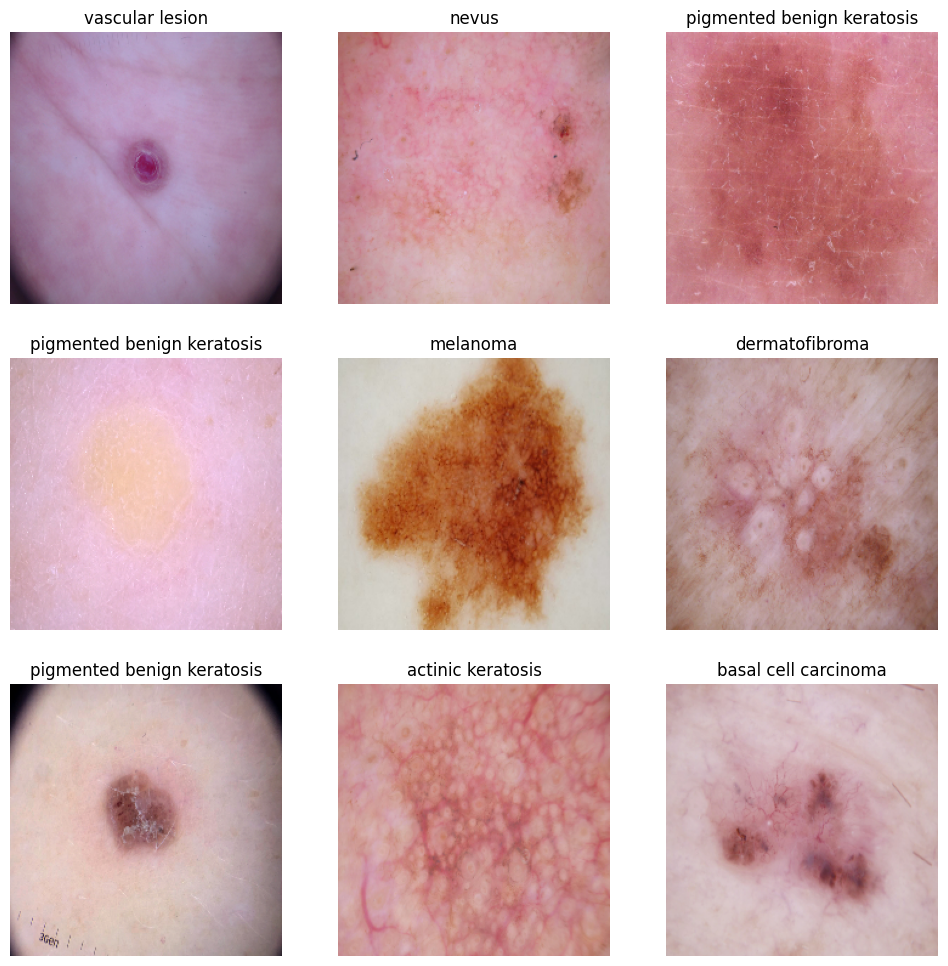

In [5]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [6]:
def build_cnn():

    model = keras.Sequential([

        layers.Rescaling(1./255, input_shape=image_size + (3,)),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(len(class_names), activation="softmax")

    ])

    return model

## Baseline CNN Model

A custom Convolutional Neural Network is implemented as a baseline model.

The model consists of:

- Convolution layers for feature extraction
- Pooling layers for dimensionality reduction
- Dense layers for classification

This model provides a reference point for comparing more advanced architectures.

In [7]:
model_1 = build_cnn()

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,441 (1.75 MB)

 Trainable params: 457,481 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

Epoch 1/30


I0000 00:00:1782654605.123954     142 service.cc:152] XLA service 0x7d5aa400c100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782654605.124007     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782654605.124012     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782654605.826280     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/56 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.0625 - loss: 3.1194 

I0000 00:00:1782654613.054838     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 195ms/step - accuracy: 0.3828 - loss: 1.7837 - val_accuracy: 0.1499 - val_loss: 2.3084
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4587 - loss: 1.5518 - val_accuracy: 0.1499 - val_loss: 2.6875
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.4905 - loss: 1.4501 - val_accuracy: 0.1477 - val_loss: 2.9014
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.5000 - loss: 1.3855 - val_accuracy: 0.1611 - val_loss: 3.3393
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.5296 - loss: 1.3286 - val_accuracy: 0.1633 - val_loss: 3.3858
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.5262 - loss: 1.3133 - val_accuracy: 0.1700 - val_loss: 3.3417
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.5363 - loss: 1.2904 - val_accuracy: 0.2662 - val_loss: 2.5646
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.5480 - loss: 1.2414 - val_accuracy: 0.3244 - val

In [10]:
loss, accuracy = model_1.evaluate(val_ds)

print(f"validation loss: {loss:.4f}")
print(f"validation accuracy: {accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.4273 - loss: 1.6585
validation loss: 1.6585
validation accuracy: 0.4273


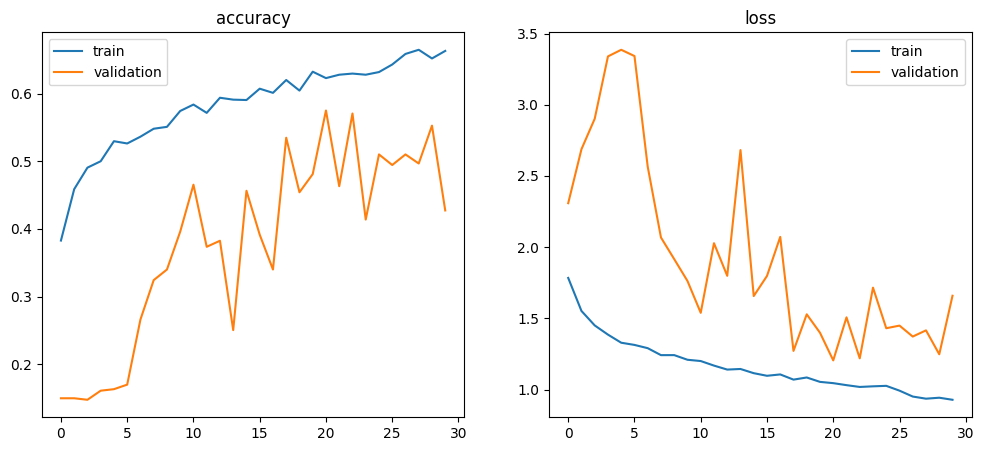

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1.history["accuracy"], label="train")
plt.plot(history_1.history["val_accuracy"], label="validation")
plt.title("accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history["loss"], label="train")
plt.plot(history_1.history["val_loss"], label="validation")
plt.title("loss")
plt.legend()

plt.show()

## CNN with Data Augmentation

The baseline CNN is enhanced by integrating image augmentation techniques.

Augmentation helps the model learn robust visual features by exposing it to different variations of the input images.

Used augmentation techniques like horizontal flipping, rotation, zoom and changing contrast

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [13]:
def build_cnn_with_augmentation():

    model = keras.Sequential([

        keras.Input(shape=image_size + (3,)),

        data_augmentation,

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(len(class_names), activation="softmax")

    ])

    return model

In [14]:
model_2 = build_cnn_with_augmentation()

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,465 (1.75 MB)

 Trainable params: 457,993 (1.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [15]:
model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.3075 - loss: 2.3840 - val_accuracy: 0.1499 - val_loss: 2.1957
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.3599 - loss: 2.0915 - val_accuracy: 0.1521 - val_loss: 2.5419
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.3956 - loss: 1.9384 - val_accuracy: 0.1544 - val_loss: 2.9285
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.4196 - loss: 1.8925 - val_accuracy: 0.1499 - val_loss: 3.3335
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.4280 - loss: 1.8196 - val_accuracy: 0.1275 - val_loss: 3.6862
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.4375 - loss: 1.7351 - val_accuracy: 0.1924 - val_loss: 3.8760
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.4520 - loss: 1.7132 - val_accuracy: 0.2148 - val_loss: 2.8861
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.4648 - loss: 1.5892 - val_accuracy: 0

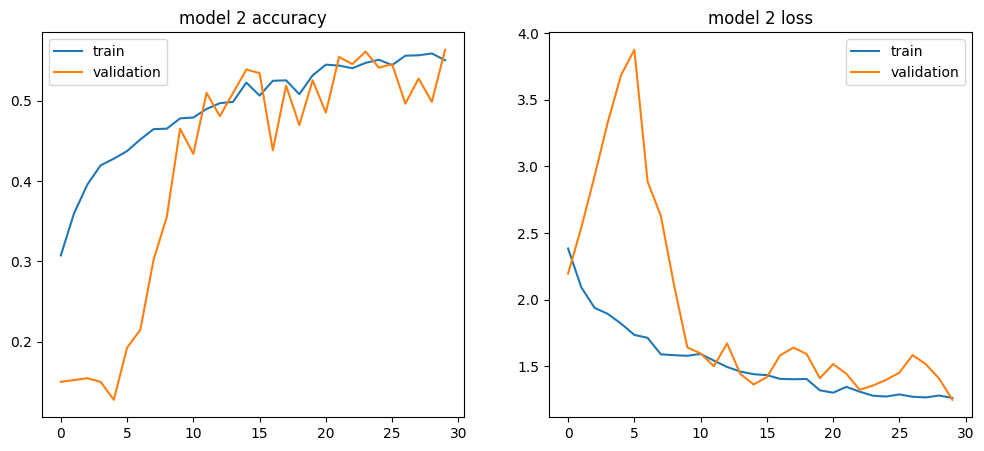

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_2.history["accuracy"], label="train")
plt.plot(history_2.history["val_accuracy"], label="validation")
plt.title("model 2 accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2.history["loss"], label="train")
plt.plot(history_2.history["val_loss"], label="validation")
plt.title("model 2 loss")
plt.legend()

plt.show()

## Handling Class Imbalance

Class imbalance is addressed by balancing the training data.

This prevents the model from being biased towards classes with higher number of samples and improves performance on minority classes.

In [18]:
!pip install Augmentor
import Augmentor
import pathlib

In [19]:
train_path = pathlib.Path(dataset_path)

for folder in sorted(train_path.iterdir()):
    if folder.is_dir():
        print(f"{folder.name:<35} {len(list(folder.glob('*')))}")

actinic keratosis                   114
basal cell carcinoma                376
dermatofibroma                      95
melanoma                            438
nevus                               357
pigmented benign keratosis          462
seborrheic keratosis                77
squamous cell carcinoma             181
vascular lesion                     139


In [20]:
path_to_training_dataset = dataset_path

output_root = "/kaggle/working/data"

os.makedirs(output_root, exist_ok=True)

for class_name in class_names:

    output_dir = os.path.join(output_root, class_name, "output")

    os.makedirs(output_dir, exist_ok=True)

    p = Augmentor.Pipeline(
        source_directory=os.path.join(path_to_training_dataset, class_name),
        output_directory=output_dir
    )

    p.rotate(probability=0.7,
             max_left_rotation=10,
             max_right_rotation=10)

    p.flip_left_right(probability=0.5)

    p.zoom_random(probability=0.5,
                  percentage_area=0.9)

    p.sample(1000)

Initialised with 114 image(s) found.
Output directory set to /kaggle/working/data/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D5AB4732B70>: 100%|██████████| 1000/1000 [00:12<00:00, 77.63 Samples/s]                 


Initialised with 376 image(s) found.
Output directory set to /kaggle/working/data/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D5AB47336B0>: 100%|██████████| 1000/1000 [00:12<00:00, 80.01 Samples/s]                 


Initialised with 95 image(s) found.
Output directory set to /kaggle/working/data/dermatofibroma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7D5AC63B35F0>: 100%|██████████| 1000/1000 [00:32<00:00, 30.52 Samples/s]                 


Initialised with 181 image(s) found.
Output directory set to /kaggle/working/data/squamous cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D5AD022F8C0>: 100%|██████████| 1000/1000 [00:12<00:00, 80.83 Samples/s]                 


Initialised with 139 image(s) found.
Output directory set to /kaggle/working/data/vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7D5B76DC4E60>: 100%|██████████| 1000/1000 [00:12<00:00, 78.48 Samples/s]                 


In [21]:
output_dir = "/kaggle/working/data"

train_ds = tf.keras.utils.image_dataset_from_directory(
    output_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    output_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

Found 9000 files belonging to 9 classes.
Using 7200 files for training.
Found 9000 files belonging to 9 classes.
Using 1800 files for validation.


In [22]:
model_3 = build_cnn_with_augmentation()

model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    # callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.3107 - loss: 2.1501 - val_accuracy: 0.1228 - val_loss: 3.1711
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step - accuracy: 0.3931 - loss: 1.8120 - val_accuracy: 0.2278 - val_loss: 2.3438
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.4376 - loss: 1.6216 - val_accuracy: 0.4683 - val_loss: 1.4296
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.4683 - loss: 1.5037 - val_accuracy: 0.5106 - val_loss: 1.3288
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.4936 - loss: 1.4090 - val_accuracy: 0.5028 - val_loss: 1.3939
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.5083 - loss: 1.3529 - val_accuracy: 0.3394 - val_loss: 2.8202
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.5312 - loss: 1.3136 - val_accuracy: 0.5211 - val_loss: 1.2436
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.5492 - loss: 1

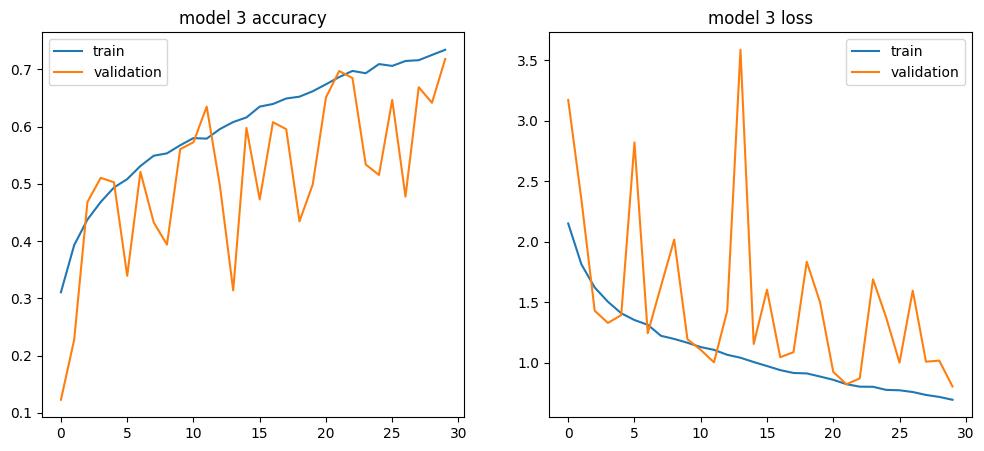

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_3.history["accuracy"], label="train")
plt.plot(history_3.history["val_accuracy"], label="validation")
plt.title("model 3 accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_3.history["loss"], label="train")
plt.plot(history_3.history["val_loss"], label="validation")
plt.title("model 3 loss")
plt.legend()

plt.show()

## EfficientNetB0 Model

EfficientNetB0 is used as a lightweight transfer learning model.

It uses compound scaling to efficiently balance network depth, width, and resolution.

The pretrained ImageNet weights are fine-tuned on the skin lesion dataset.

In [24]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow import keras
from tensorflow.keras import layers, Model

In [25]:
def build_efficientnet():

    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=image_size + (3,)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=image_size + (3,))

    x = data_augmentation(inputs)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        256,
        activation="swish"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        len(class_names),
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    return model, base_model

In [26]:
model_4, base_model = build_efficientnet()

model_4.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,964 (16.73 MB)

 Trainable params: 333,321 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [27]:
model_4.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [28]:
history_4 = model_4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

Epoch 1/30


E0000 00:00:1782656262.215269      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.2654 - loss: 2.3643 - val_accuracy: 0.4306 - val_loss: 1.6262
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.4024 - loss: 1.8428 - val_accuracy: 0.5083 - val_loss: 1.3522
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.4418 - loss: 1.6616 - val_accuracy: 0.5611 - val_loss: 1.2260
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.4790 - loss: 1.5267 - val_accuracy: 0.5833 - val_loss: 1.1520
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.5061 - loss: 1.4323 - val_accuracy: 0.6139 - val_loss: 1.0782
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.5249 - loss: 1.3599 - val_accuracy: 0.6206 - val_loss: 1.0335
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.5349 - loss: 1.3099 - val_accuracy: 0.6389 - val_loss: 0.9974
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.5522 - loss: 1.2791 - val_accur

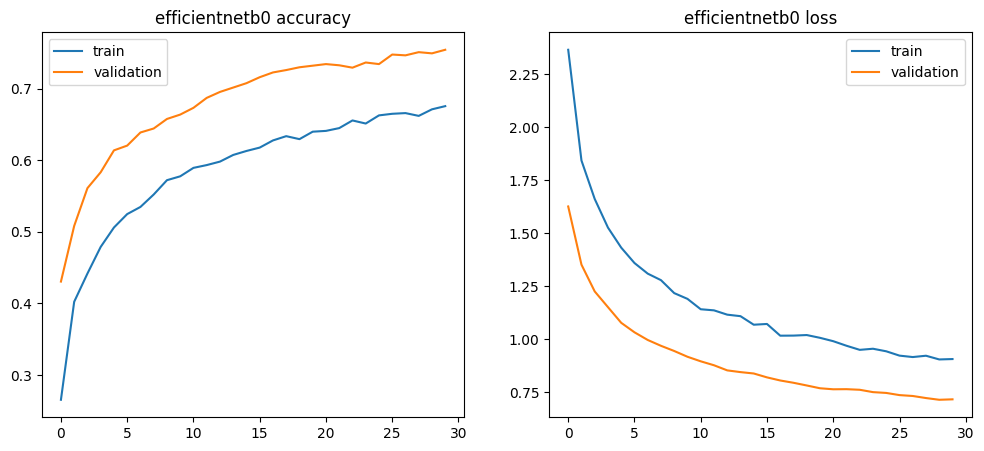

In [29]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_4.history["accuracy"], label="train")
plt.plot(history_4.history["val_accuracy"], label="validation")
plt.title("efficientnetb0 accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_4.history["loss"], label="train")
plt.plot(history_4.history["val_loss"], label="validation")
plt.title("efficientnetb0 loss")
plt.legend()

plt.show()

In [30]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [31]:
model_4.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history_4_finetune = model_4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)

Epoch 1/20


E0000 00:00:1782656935.518986      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.6854 - loss: 0.8687 - val_accuracy: 0.7606 - val_loss: 0.6970
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.7036 - loss: 0.8357 - val_accuracy: 0.7644 - val_loss: 0.6789
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.7053 - loss: 0.8199 - val_accuracy: 0.7622 - val_loss: 0.6787
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.7013 - loss: 0.8253 - val_accuracy: 0.7633 - val_loss: 0.6628
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - accuracy: 0.7156 - loss: 0.7886 - val_accuracy: 0.7667 - val_loss: 0.6566
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.7185 - loss: 0.7753 - val_accuracy: 0.7672 - val_loss: 0.6475
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - accuracy: 0.7246 - loss: 0.7667 - val_accuracy: 0.7667 - val_loss: 0.6446
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - accuracy: 0.7268 - loss: 0.7583 - val

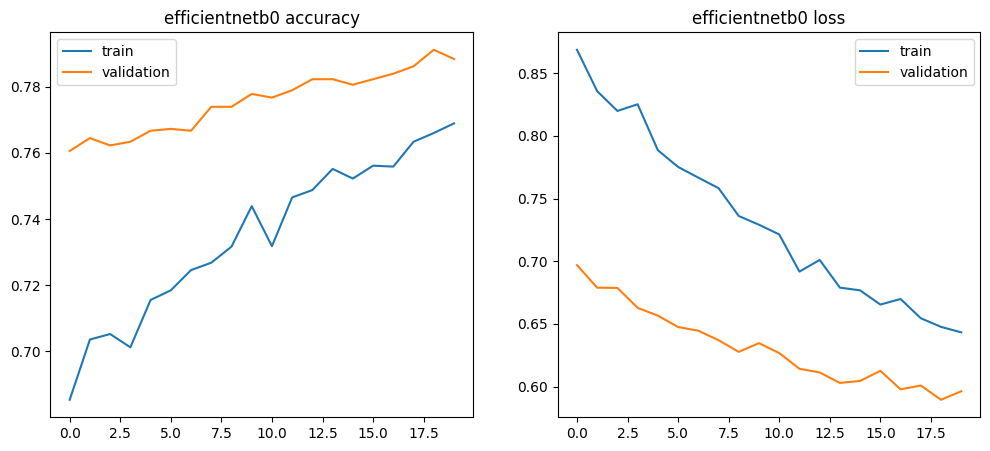

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_4_finetune.history["accuracy"], label="train")
plt.plot(history_4_finetune.history["val_accuracy"], label="validation")
plt.title("efficientnetb0 accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_4_finetune.history["loss"], label="train")
plt.plot(history_4_finetune.history["val_loss"], label="validation")
plt.title("efficientnetb0 loss")
plt.legend()

plt.show()

## ResNet50 Model

ResNet50 is a deep convolutional neural network that uses residual connections to solve the vanishing gradient problem.

The pretrained model is fine-tuned for skin lesion classification.

In [33]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow import keras


def build_resnet():

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=image_size + (3,)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=image_size + (3,))

    x = data_augmentation(inputs)

    # ResNet preprocessing
    x = layers.Lambda(preprocess_input)(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        len(class_names),
        activation="softmax"
    )(x)


    model = Model(inputs, outputs)

    return model, base_model

In [34]:
resnet_model, resnet_base = build_resnet()

resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [35]:
history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 52s 193ms/step - accuracy: 0.3299 - loss: 2.1191 - val_accuracy: 0.5317 - val_loss: 1.3577
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 39s 174ms/step - accuracy: 0.4796 - loss: 1.5671 - val_accuracy: 0.5856 - val_loss: 1.1726
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - accuracy: 0.5331 - loss: 1.3731 - val_accuracy: 0.6239 - val_loss: 1.0716
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - accuracy: 0.5649 - loss: 1.2483 - val_accuracy: 0.6361 - val_loss: 1.0115
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 177ms/step - accuracy: 0.5875 - loss: 1.1616 - val_accuracy: 0.6672 - val_loss: 0.9585
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - accuracy: 0.6054 - loss: 1.1117 - val_accuracy: 0.6856 - val_loss: 0.8993
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - accuracy: 0.6257 - loss: 1.0530 - val_accuracy: 0.6922 - val_loss: 0.8778
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - accuracy: 0.6410 - loss: 0

In [36]:
resnet_base.trainable = True


for layer in resnet_base.layers[:-40]:
    layer.trainable = False


# keep BatchNorm frozen
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False


resnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 65s 241ms/step - accuracy: 0.7717 - loss: 0.6198 - val_accuracy: 0.7983 - val_loss: 0.5570
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.7921 - loss: 0.5734 - val_accuracy: 0.8389 - val_loss: 0.4674
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.8061 - loss: 0.5332 - val_accuracy: 0.8039 - val_loss: 0.5335
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 228ms/step - accuracy: 0.8208 - loss: 0.4802 - val_accuracy: 0.8244 - val_loss: 0.4753
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.8522 - loss: 0.4129 - val_accuracy: 0.8450 - val_loss: 0.4447
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 228ms/step - accuracy: 0.8624 - loss: 0.3876 - val_accuracy: 0.8617 - val_loss: 0.3884
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 227ms/step - accuracy: 0.8672 - loss: 0.3611 - val_accuracy: 0.8561 - val_loss: 0.3884
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 51s 228ms/step - accuracy: 0.8758 - loss: 0

## Model Evaluation

The trained models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

Since this is a medical classification problem, recall and F1-score are important indicators along with accuracy.

In [37]:
models = [
    (model_1, "CNN without augmentation"),
    (model_2, "CNN with augmentation"),
    (model_3, "CNN with Class Balance"),
    (model_4, "EfficientNetB0"),
    (resnet_model, "ResNet50")
]

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np
import pandas as pd


def evaluate_model(model, name):

    y_true = []
    y_pred = []

    for images, labels in val_ds:
        probs = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(probs, axis=1))


    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            average="weighted"
        )
    }



results = []

for model, name in models:
    results.append(
        evaluate_model(model, name)
    )


results_df = pd.DataFrame(results)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,CNN without augmentation,0.395000,0.556006,0.395000,0.351660
1,CNN with augmentation,0.482778,0.494089,0.482778,0.452864
2,CNN with Class Balance,0.718333,0.729135,0.718333,0.713039
3,EfficientNetB0,0.788333,0.808597,0.788333,0.790186
4,ResNet50,0.899444,0.902889,0.899444,0.898421


## Comparison of Models

All trained models are compared based on their evaluation metrics.

This comparison helps identify the best-performing architecture for skin lesion classification.

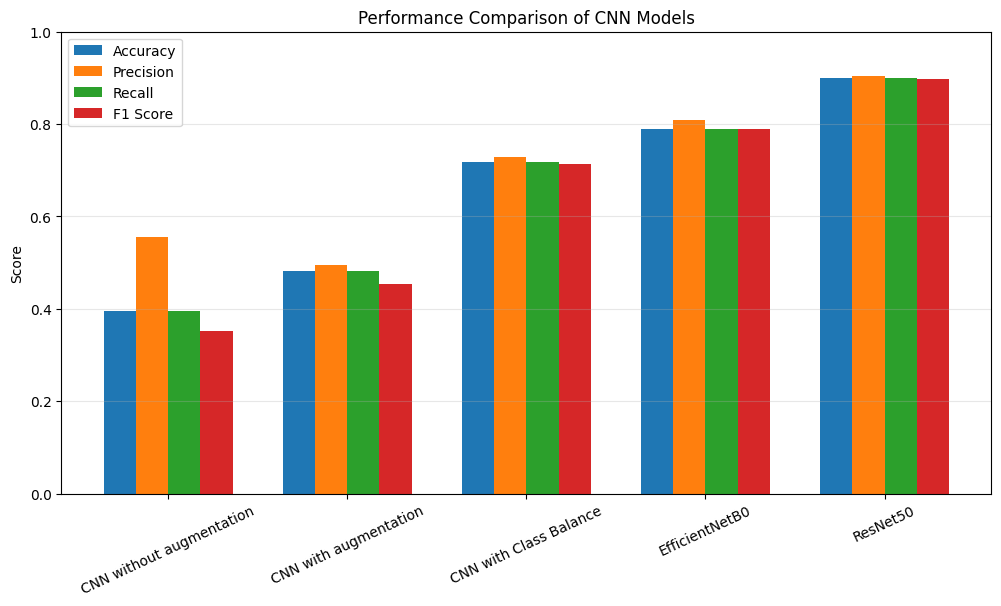

In [39]:
import matplotlib.pyplot as plt


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]


x = np.arange(len(results_df["Model"]))

width = 0.18


plt.figure(figsize=(12,6))


for i, metric in enumerate(metrics):

    plt.bar(
        x + i*width,
        results_df[metric],
        width,
        label=metric
    )


plt.xticks(
    x + width*1.5,
    results_df["Model"],
    rotation=25
)


plt.ylabel("Score")

plt.title(
    "Performance Comparison of CNN Models"
)

plt.ylim(0,1)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## Final Results and Conclusion

The best-performing model is selected based on accuracy, F1-score, and class-wise performance.

Transfer learning models significantly outperform custom CNN architectures due to their ability to extract rich visual features from pretrained networks.

The final model provides an efficient approach for automated skin lesion classification.

In [42]:
test_path = '/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train'

In [43]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2239 files belonging to 9 classes.


In [44]:
final_model = resnet_model

In [45]:
test_loss, test_acc = final_model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.8808 - loss: 0.3475
Test Accuracy: 0.8807503581047058


In [46]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = final_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                            precision    recall  f1-score   support

         actinic keratosis       0.64      0.89      0.75       114
      basal cell carcinoma       0.99      0.86      0.92       376
            dermatofibroma       0.87      1.00      0.93        95
                  melanoma       0.94      0.79      0.86       438
                     nevus       0.92      0.80      0.86       357
pigmented benign keratosis       0.87      0.98      0.92       462
      seborrheic keratosis       0.49      0.91      0.63        77
   squamous cell carcinoma       0.96      0.88      0.92       181
           vascular lesion       1.00      0.99      1.00       139

                  accuracy                           0.88      2239
                 macro avg       0.85      0.90      0.86      2239
              weighted avg       0.90      0.88      0.89      2239



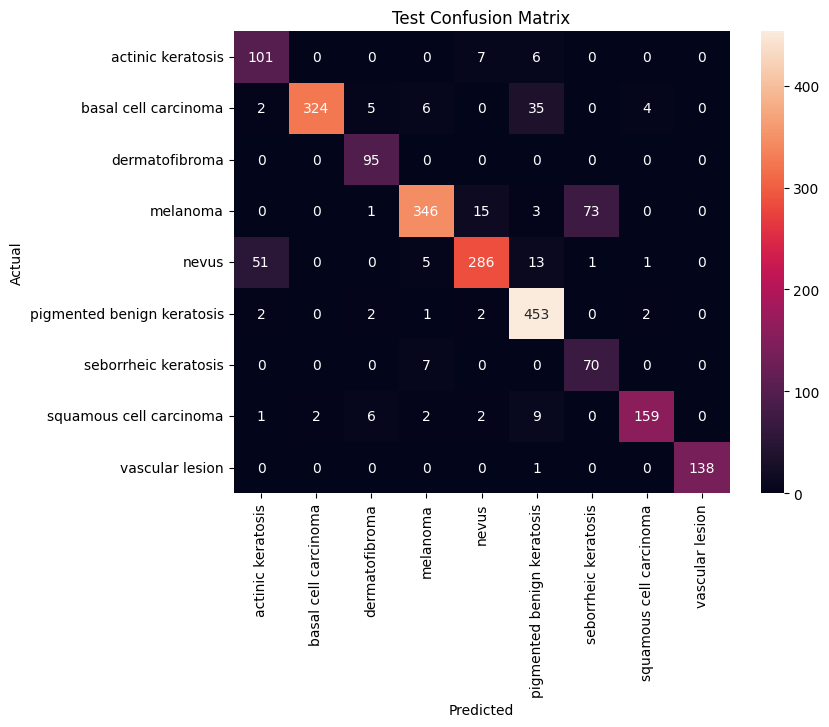

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")

plt.show()

In [40]:
# model_4.save("efficientnet_model.keras")
# resnet_model.save("resnet_model.keras")